# Analyse exploratoire

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


In [4]:
data_path  = "../data/diabetes.csv"
df = pd.read_csv(data_path)
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


array([[<Axes: title={'center': 'Pregnancies'}>,
        <Axes: title={'center': 'Glucose'}>,
        <Axes: title={'center': 'BloodPressure'}>],
       [<Axes: title={'center': 'SkinThickness'}>,
        <Axes: title={'center': 'Insulin'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'DiabetesPedigreeFunction'}>,
        <Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Outcome'}>]], dtype=object)

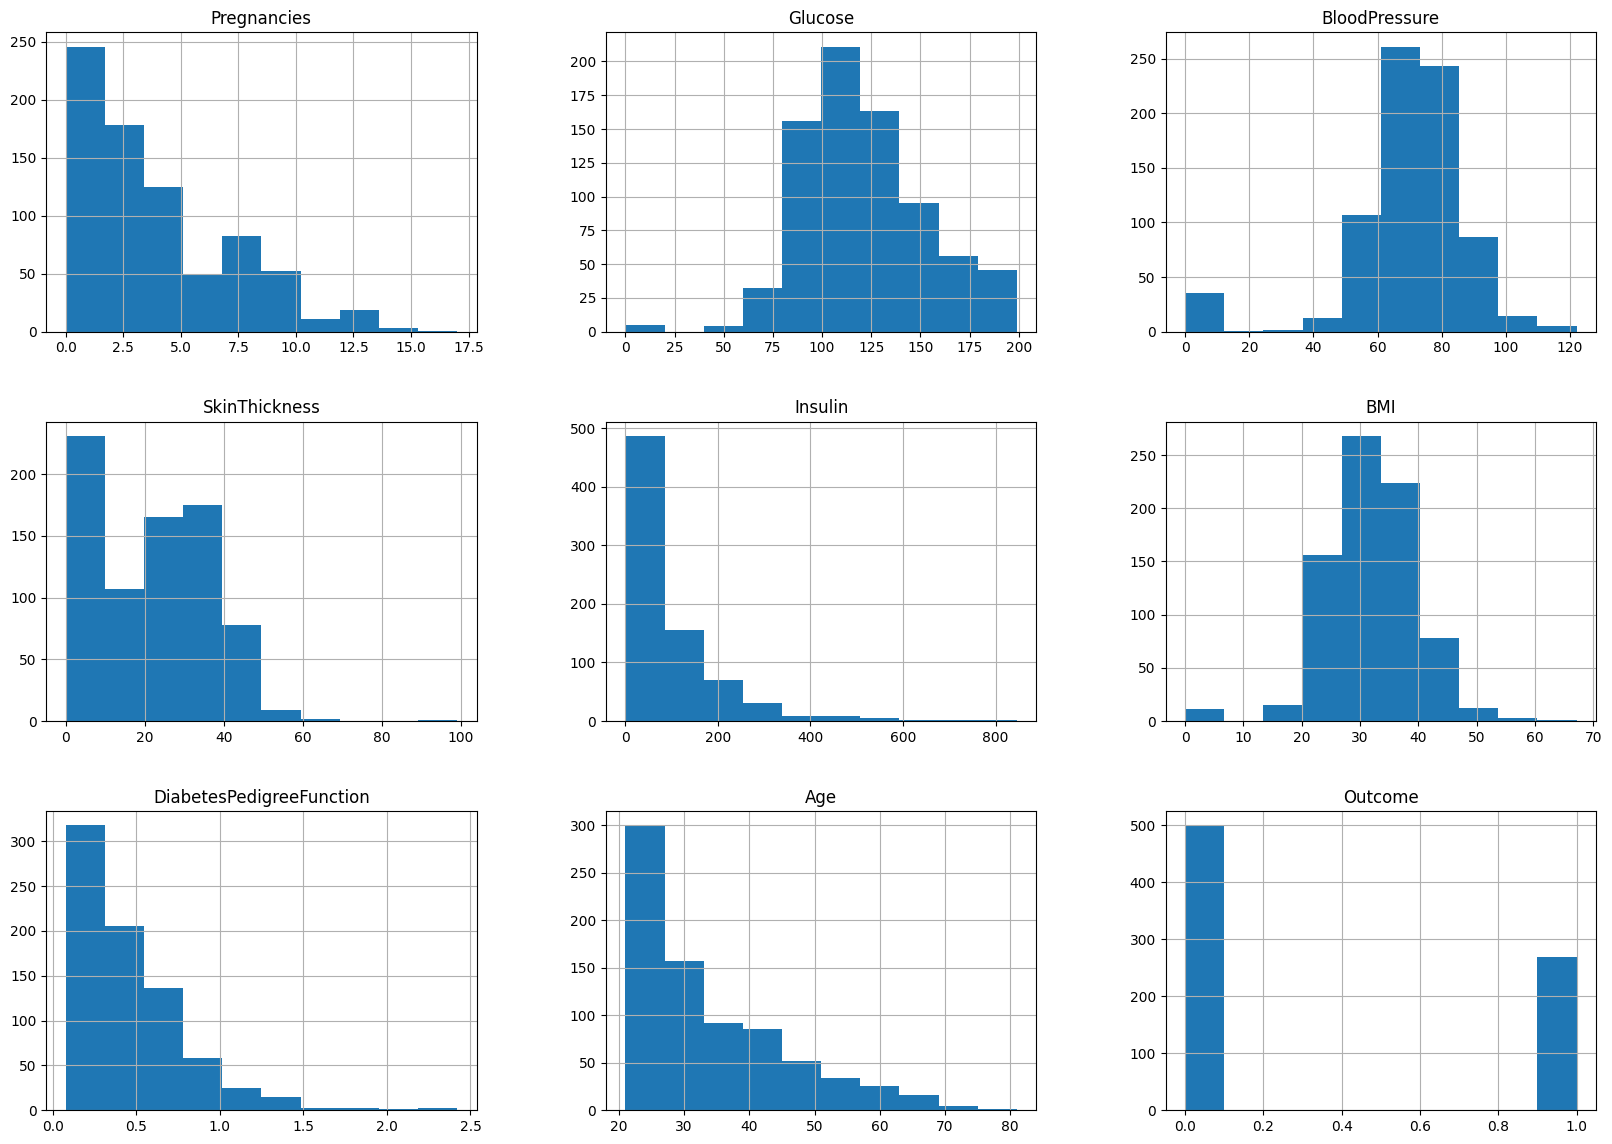

In [5]:
df.hist(figsize=(20, 14))

In [51]:
#transformation en matrice numpy
data = df.values

#X matrice des var. explicatives
x = data[:,0:8]

#y vecteur de la var. à prédire
y = data[:,8]

#subdivision des données – éch.test = 300 ; éch.app = 768 – éch.test = 468
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 300,random_state=0)
print(x_train.shape, x_test.shape, y_train.shape, y_test.shape)

(468, 8) (300, 8) (468,) (300,)


In [ ]:
# pd.crosstab(
#     index=df["Glucose"], columns=df["Age"]
# )

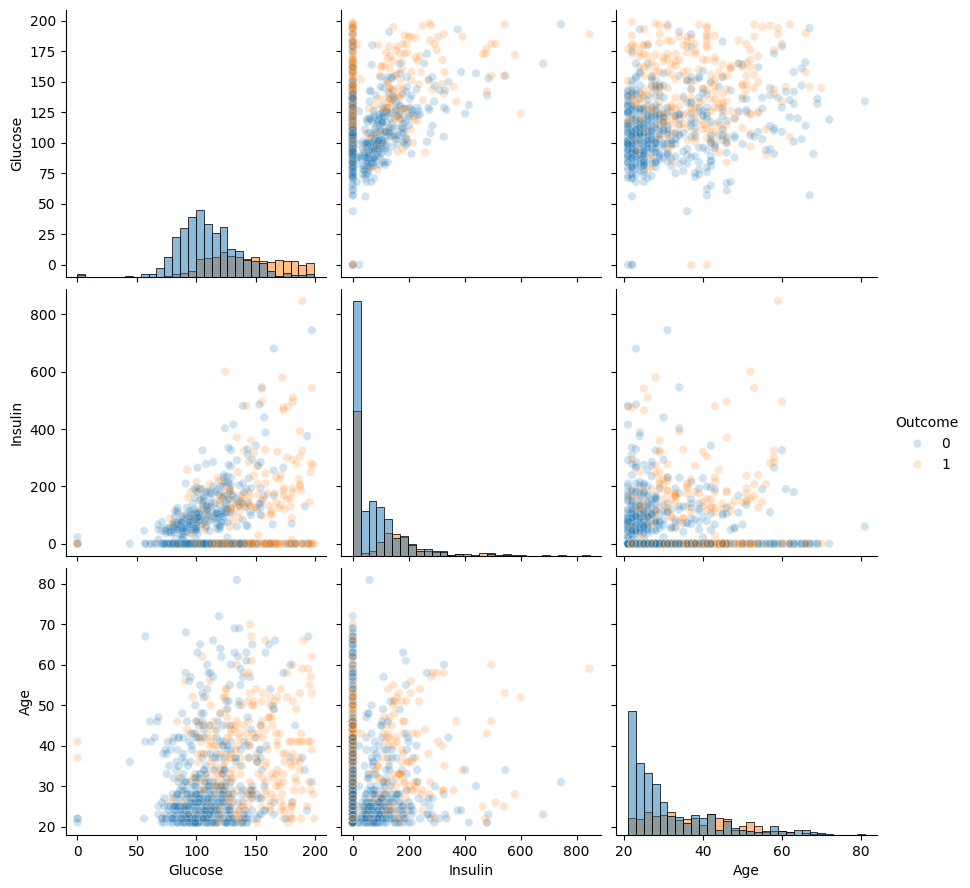

In [9]:
import seaborn as sns

# We plot a subset of the data to keep the plot readable and make the plotting
# faster
n_samples_to_plot = 5000
columns = ["Glucose", "Insulin", "Age"]
_ = sns.pairplot(
    data=df[:n_samples_to_plot],
    vars=columns,
    hue="Outcome",
    plot_kws={"alpha": 0.2},
    height=3,
    diag_kind="hist",
    diag_kws={"bins": 30},
)

# Conception et validtion du model

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# pipe = make_pipeline(
#     StandardScaler(),
#     LogisticRegression(solver="liblinear")
# )

# pipe.fit(x_train, y_train)
# y_pred = pipe.predict(x_test)

scaler = StandardScaler().set_output(transform="pandas")
data_train_scaled = scaler.fit_transform(x_train)
data_train_scaled.describe()

,x0,x1,x2,x3,x4,x5,x6,x7
count,4.680000e+02,4.680000e+02,4.680000e+02,4.680000e+02,4.680000e+02,4.680000e+02,4.680000e+02,4.680000e+02
mean,-4.744543e-17,6.832142e-17,2.770813e-16,3.036507e-17,2.277381e-17,-5.184836e-15,-2.277381e-17,1.214603e-16
std,1.001070e+00,1.001070e+00,1.001070e+00,1.001070e+00,1.001070e+00,1.001070e+00,1.001070e+00,1.001070e+00
min,-1.126726e+00,-3.787071e+00,-3.790298e+00,-1.344213e+00,-7.319070e-01,-4.080423e+00,-1.143133e+00,-1.053731e+00
25%,-8.313157e-01,-6.947753e-01,-3.463286e-01,-1.344213e+00,-7.319070e-01,-5.983164e-01,-6.887121e-01,-7.997067e-01
50%,-2.404945e-01,-7.631626e-02,8.416752e-02,1.681813e-01,-3.193452e-01,2.213181e-02,-2.933068e-01,-3.763325e-01
75%,6.457372e-01,6.426424e-01,5.146637e-01,7.313068e-01,4.445068e-01,5.539445e-01,4.163571e-01,5.762592e-01
max,3.304432e+00,2.335674e+00,2.774769e+00,2.710291e+00,6.179524e+00,4.415918e+00,5.749902e+00,4.026758e+00


In [23]:

lr = LogisticRegression(solver="liblinear")
# modele = lr.fit(x_train, y_train)
modele_scaled = lr.fit(data_train_scaled, y_train)
print(modele_scaled.coef_, modele_scaled.intercept_)

## Cross-validation

In [47]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score

nb_split = 5
cv = KFold(n_splits=nb_split, shuffle=True, random_state=42)
model_cv = make_pipeline(
    StandardScaler(),
    LogisticRegression(solver="liblinear")
)

scores = cross_val_score(model_cv, x, y, cv=cv, scoring="accuracy")
print(scores.mean(), scores.std())

0.7695526695526695 0.024755601732574756


In [46]:
from sklearn import metrics

#prediction sur l'échantillon test
x_test_scaled = scaler.transform(x_test)
y_pred = modele_scaled.predict(x_test_scaled)

score = modele_scaled.score(x_test_scaled, y_test)
print(
    f"The accuracy using a Logistic regressio is {score:.3f} "
)

#matrice de confusion
cm = metrics.confusion_matrix(y_test, y_pred)
print(cm)

# #taux de succès
# acc = metrics.accuracy_score(y_test, y_pred)
# print(acc) # 0.793 = (184 + 54)/ (184 + 17 + 45 + 54)

# #taux d'erreur
# err = 1.0 - acc
# print(err) # 0.206 = 1.0 – 0.793

# #sensibilité (ou rappel)
# se = metrics.recall_score(y_test, y_pred)
# print(se) # 0.545 = 54 / (45+ 54)



The accuracy using a Logistic regressio is 0.787 
[[184  17]
 [ 47  52]]


# Train model on all data

In [52]:
import joblib

# Train final model on ALL data for production deployment
final_pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(solver="liblinear")
)

final_pipeline.fit(x, y)

# Save the model
joblib.dump(final_pipeline, "../models/diabetes_model.pkl")
print("✓ Model saved to models/diabetes_model.pkl")

# Verify model can be loaded
loaded_model = joblib.load("../models/diabetes_model.pkl")
print("✓ Model loaded successfully")

# Test prediction with loaded model
sample_input = x[0:1]  # First sample
print(sample_input)
prediction = loaded_model.predict(sample_input)
probability = loaded_model.predict_proba(sample_input)
print(f"Sample prediction: {prediction[0]}")
print(f"Probability: {probability[0]}")


✓ Model saved to models/diabetes_model.pkl
✓ Model loaded successfully
[[  6.    148.     72.     35.      0.     33.6     0.627  50.   ]]
Sample prediction: 1.0
Probability: [0.28120104 0.71879896]
